# 3. Улучшение качества данных

<img src='https://elitedatascience.com/wp-content/uploads/2018/05/What-Goes-Into-a-Successful-Model.jpg'>

## Несбалансированные данные

**OverSmapling, UnderSampling**

<img src="https://drive.google.com/thumbnail?id=10X03w36R2H84keZZDHWGAAFCXTvrqqhW&sz=w1200">


**OverSampling - SMOTE**

<img src="https://drive.google.com/thumbnail?id=1Mevc-rUt2zAhXspv0Ac3Qe-RccKGuPvs&sz=w1200">


**UnderSampling - Tomek Links**

<img src="https://drive.google.com/thumbnail?id=1sJAzP2P5pEO4ZnzWkUxfUeLm618zm90f&sz=w1200">

**Подключение библиотек и скриптов**

In [1]:
import pandas as pd

from sklearn.model_selection import train_test_split

# Ссылка на файл

https://drive.google.com/file/d/15hzSNrUhEil6INJJMpA1mW-a7_IXKFlK/view?usp=sharing

In [2]:
!gdown 15hzSNrUhEil6INJJMpA1mW-a7_IXKFlK -O employee.csv

Downloading...
From: https://drive.google.com/uc?id=15hzSNrUhEil6INJJMpA1mW-a7_IXKFlK
To: D:\MyJupyterNotebook\Learning\GitHub\01_data_analysis\employee.csv

  0%|          | 0.00/603k [00:00<?, ?B/s]
 87%|########6 | 524k/603k [00:00<00:00, 1.17MB/s]
100%|##########| 603k/603k [00:00<00:00, 1.31MB/s]


In [3]:
DATASET_PATH = 'employee.csv'
df = pd.read_csv(DATASET_PATH)
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department,salary,left
0,0.38,0.53,NaN,157.0,3,0.0,0,sales,low,1
1,0.80,0.86,5.0,262.0,6,0.0,0,sales,medium,1
2,0.11,0.88,7.0,272.0,4,0.0,0,sales,medium,1
3,0.72,0.87,5.0,NaN,5,0.0,0,sales,low,1
4,0.37,0.52,2.0,159.0,3,0.0,0,sales,low,1


In [4]:
df.columns

Index(['satisfaction_level', 'last_evaluation', 'number_project',
       'average_montly_hours', 'time_spend_company', 'Work_accident',
       'promotion_last_5years', 'department', 'salary', 'left'],
      dtype='object')

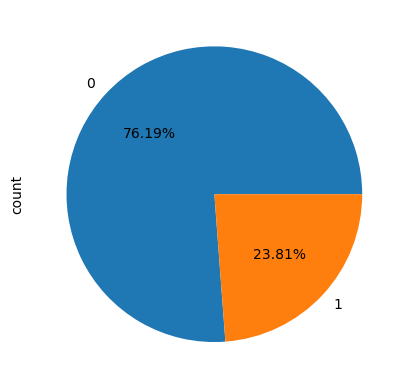

In [5]:
df['left'].value_counts().plot(kind='pie', autopct='%.2f%%');

#### Предобработка данных

In [6]:
X = df.drop(columns='left')
y = df['left']

X_train, X_test, y_train, y_test = train_test_split(X, y,
                                                    test_size=0.2,
                                                    shuffle=True,
                                                    stratify=y,
                                                    random_state=2)
X_train.shape, X_test.shape

((11999, 9), (3000, 9))

In [7]:
y_train.value_counts(normalize=True)

left
0    0.761897
1    0.238103
Name: proportion, dtype: float64

In [8]:
y_test.value_counts(normalize=True)

left
0    0.762
1    0.238
Name: proportion, dtype: float64

In [9]:
X_train.isna().sum()

satisfaction_level          0
last_evaluation          2324
number_project           1368
average_montly_hours     1348
time_spend_company          0
Work_accident             789
promotion_last_5years       0
department                  0
salary                   2144
dtype: int64

In [10]:
num_features = ['satisfaction_level', 'last_evaluation', 'number_project', 'average_montly_hours', 'time_spend_company']
bin_features = ['Work_accident', 'promotion_last_5years']
cat_features = ['department', 'salary']

In [11]:
from sklearn.pipeline import make_pipeline, FeatureUnion
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder


num_pipe = make_pipeline(
    SimpleImputer(strategy="median"),
    StandardScaler()
)

cat_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent'),
    OneHotEncoder(handle_unknown="ignore")
)

bin_pipe = make_pipeline(
    SimpleImputer(strategy='most_frequent')
)


preprocessor = ColumnTransformer(
    transformers=[
        ("num", num_pipe, num_features),
        ("cat", cat_pipe, cat_features),
        ("bin", bin_pipe, bin_features)
    ]
)


In [12]:
X_train.shape

(11999, 9)

In [13]:
X_train.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department,salary
566,0.11,0.79,7.0,310.0,4,0.0,0,hr,NaN
2323,0.86,0.70,5.0,160.0,3,0.0,0,technical,medium
11992,0.62,NaN,3.0,237.0,3,1.0,0,IT,medium
1343,0.44,0.54,2.0,150.0,3,0.0,0,support,NaN
8165,0.60,0.59,5.0,NaN,2,0.0,0,RandD,low


In [14]:
X_train = preprocessor.fit_transform(X_train)
X_test = preprocessor.transform(X_test)

In [15]:
X.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department,salary
0,0.38,0.53,NaN,157.0,3,0.0,0,sales,low
1,0.80,0.86,5.0,262.0,6,0.0,0,sales,medium
2,0.11,0.88,7.0,272.0,4,0.0,0,sales,medium
3,0.72,0.87,5.0,NaN,5,0.0,0,sales,low
4,0.37,0.52,2.0,159.0,3,0.0,0,sales,low


In [16]:
X_train

array([[-2.01498367,  0.47374585,  2.73487966, ...,  0.        ,
         0.        ,  0.        ],
       [ 0.9998486 , -0.11283362,  1.01533339, ...,  1.        ,
         0.        ,  0.        ],
       [ 0.03510227,  0.01751737, -0.70421288, ...,  1.        ,
         1.        ,  0.        ],
       ...,
       [ 0.35668438,  0.14786837, -0.70421288, ...,  1.        ,
         0.        ,  0.        ],
       [-1.81399485,  0.01751737,  0.15556025, ...,  1.        ,
         0.        ,  0.        ],
       [-1.81399485,  0.01751737,  1.01533339, ...,  1.        ,
         0.        ,  0.        ]], shape=(11999, 20))

In [17]:
X_train.shape

(11999, 20)

### imblearn

In [18]:
def balance_df_by_target(df, target_idx, method='over'):

    assert method in ['over', 'under', 'tomek', 'smote'], 'Неверный метод сэмплирования'

    df[target_idx] = df[target_idx].astype('int')
    target_counts = df[target_idx].value_counts()

    major_class_name = target_counts.argmax()
    minor_class_name = target_counts.argmin()

    disbalance_coeff = int(target_counts[major_class_name] / target_counts[minor_class_name]) - 1
    if method == 'over':
        for i in range(disbalance_coeff):
            sample = df[df[target_idx] == minor_class_name].sample(target_counts[minor_class_name])

            # можно заменить на .concat
            df = pd.concat([df, sample], ignore_index=True)

    elif method == 'under':
        df_ = df.copy()
        df = df_[df_[target_idx] == minor_class_name]
        tmp = df_[df_[target_idx] == major_class_name]

        # можно заменить на .concat
        df = pd.concat(
            [df, tmp.iloc[
                      np.random.randint(0, tmp.shape[0], target_counts[minor_class_name])
                  ]
            ], ignore_index=True)

    elif method == 'tomek':
        from imblearn.under_sampling import TomekLinks
        tl = TomekLinks()
        X_tomek, y_tomek = tl.fit_resample(df.drop(columns=target_idx), df[target_idx])
        df = pd.concat([X_tomek, y_tomek], axis=1)

    elif method == 'smote':
        from imblearn.over_sampling import SMOTE
        smote = SMOTE()
        X_smote, y_smote = smote.fit_resample(df.drop(columns=target_idx), df[target_idx])
        df = pd.concat([X_smote, y_smote], axis=1)

    return df.sample(frac=1)

In [19]:
def get_metrics(report):
    f1_macro = report['macro avg']['f1-score']
    f1_0 = report['0']['f1-score']
    f1_1 = report['1']['f1-score']
    return f1_macro, f1_0, f1_1

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report


def run_experiment(X_train, X_test, y_train, y_test, method='not'):
    assert method in ['not', 'over', 'under', 'tomek', 'smote'], 'Неправильный метод сэмплирования'


    model = LogisticRegression()
    model.fit(X_train, y_train)
    pred_train = model.predict(X_train)
    pred_test = model.predict(X_test)

    report_train = classification_report(y_train, pred_train, output_dict=True)
    report_test = classification_report(y_test, pred_test, output_dict=True)
    f1_macro_train, f1_0_train, f1_1_train = get_metrics(report_train)
    f1_macro_test, f1_0_test, f1_1_test = get_metrics(report_test)

    stata = {
        f'f1_macro_train': f1_macro_train,
        f'f1_macro_test': f1_macro_test,
        f'f1_0_train': f1_0_train,
        f'f1_0_test': f1_0_test,
        f'f1_1_train': f1_1_train,
        f'f1_1_test': f1_1_test,
        f'method': method
    }

    return stata, model

In [21]:
stata = pd.DataFrame()

*Ничего не делаем с данными*

In [22]:
%%time
stata_not_balanced, models_not_balanced = run_experiment(X_train, X_test, y_train, y_test, method='not')
stata_not_balanced

CPU times: total: 15.6 ms
Wall time: 78.9 ms


{'f1_macro_train': 0.63620047433665,
 'f1_macro_test': 0.630268464622211,
 'f1_0_train': 0.8670201917193555,
 'f1_0_test': 0.8652944772773589,
 'f1_1_train': 0.4053807569539444,
 'f1_1_test': 0.39524245196706315,
 'method': 'not'}

In [23]:
stata_not_balanced_df = pd.DataFrame([stata_not_balanced])
stata = pd.concat([stata, stata_not_balanced_df], ignore_index=True)
stata

,f1_macro_train,f1_macro_test,f1_0_train,f1_0_test,f1_1_train,f1_1_test,method
0,0.6362,0.630268,0.86702,0.865294,0.405381,0.395242,not


*Oversampling*

In [24]:
TARGET_NAME = 'left'

In [25]:
import numpy as np

df_for_balancing = pd.DataFrame(np.c_[X_train, y_train.values])
df_for_balancing.head()

,0,1,2,3,4,5,6,7,8,9,...,11,12,13,14,15,16,17,18,19,20
0,-2.014984,0.473746,2.734880,2.328398,0.341203,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,0.999849,-0.112834,1.015333,-0.861178,-0.340238,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0
2,0.035102,0.017517,-0.704213,0.776138,-0.340238,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
3,-0.688457,-1.155642,-1.563986,-1.073816,-0.340238,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
4,-0.045293,-0.829764,1.015333,-0.031888,-1.021679,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


In [26]:
TARGET_NAME = 20
df_balanced = balance_df_by_target(df_for_balancing, TARGET_NAME, method='over')

df_balanced[TARGET_NAME].value_counts()

20
0    9142
1    8571
Name: count, dtype: int64

In [27]:
X_train_balanced = df_balanced.drop(columns=TARGET_NAME)
y_train_balanced = df_balanced[TARGET_NAME]

In [28]:
%%time
stata_balanced_over, models_over = run_experiment(X_train_balanced, X_test, y_train_balanced, y_test, method='over')
stata_balanced_over

CPU times: total: 62.5 ms
Wall time: 93.7 ms


{'f1_macro_train': 0.7601114843615333,
 'f1_macro_test': 0.7083756979748312,
 'f1_0_train': 0.7655016288443487,
 'f1_0_test': 0.8274556213017752,
 'f1_1_train': 0.7547213398787179,
 'f1_1_test': 0.5892957746478873,
 'method': 'over'}

In [29]:
# можно заменить на .concat
stata_balanced_over_df = pd.DataFrame([stata_balanced_over])
stata = pd.concat([stata, stata_balanced_over_df], ignore_index=True)
stata

,f1_macro_train,f1_macro_test,f1_0_train,f1_0_test,f1_1_train,f1_1_test,method
0,0.636200,0.630268,0.867020,0.865294,0.405381,0.395242,not
1,0.760111,0.708376,0.765502,0.827456,0.754721,0.589296,over


*Undersampling*

In [30]:
df_balanced = balance_df_by_target(df_for_balancing, TARGET_NAME, method='under')

df_balanced[TARGET_NAME].value_counts()

20
0    2857
1    2857
Name: count, dtype: int64

In [31]:
X_train_balanced = df_balanced.drop(columns=TARGET_NAME)
y_train_balanced = df_balanced[TARGET_NAME]

In [32]:
%%time
stata_balanced_under, models_under = run_experiment(X_train_balanced, X_test, y_train_balanced, y_test, method='under')
stata_balanced_under

CPU times: total: 31.2 ms
Wall time: 59.7 ms


{'f1_macro_train': 0.755076873225228,
 'f1_macro_test': 0.7054566804378013,
 'f1_0_train': 0.7504904583556269,
 'f1_0_test': 0.8204267561735795,
 'f1_1_train': 0.7596632880948291,
 'f1_1_test': 0.590486604702023,
 'method': 'under'}

In [33]:
# можно заменить на .concat
stata_balanced_under_df = pd.DataFrame([stata_balanced_under])
stata = pd.concat([stata, stata_balanced_under_df], ignore_index=True)
stata

,f1_macro_train,f1_macro_test,f1_0_train,f1_0_test,f1_1_train,f1_1_test,method
0,0.636200,0.630268,0.867020,0.865294,0.405381,0.395242,not
1,0.760111,0.708376,0.765502,0.827456,0.754721,0.589296,over
2,0.755077,0.705457,0.750490,0.820427,0.759663,0.590487,under


*Undersampling (Tomeklinks)*

In [34]:
df_balanced = balance_df_by_target(df_for_balancing, TARGET_NAME, method='tomek')
df_balanced[TARGET_NAME].value_counts()

20
0    9011
1    2857
Name: count, dtype: int64

In [35]:
X_train_balanced = df_balanced.drop(columns=TARGET_NAME)
y_train_balanced = df_balanced[TARGET_NAME]

In [36]:
%%time
stata_balanced_tomek, models_tomek = run_experiment(X_train_balanced, X_test, y_train_balanced, y_test, method='tomek')
stata_balanced_tomek

CPU times: total: 78.1 ms
Wall time: 91.4 ms


{'f1_macro_train': 0.6432665048168553,
 'f1_macro_test': 0.6402310650313933,
 'f1_0_train': 0.8666908450339361,
 'f1_0_test': 0.8658061872567097,
 'f1_1_train': 0.4198421645997745,
 'f1_1_test': 0.41465594280607687,
 'method': 'tomek'}

In [37]:
stata_balanced_tomek_df = pd.DataFrame([stata_balanced_tomek])
stata = pd.concat([stata, stata_balanced_tomek_df], ignore_index=True)
stata

,f1_macro_train,f1_macro_test,f1_0_train,f1_0_test,f1_1_train,f1_1_test,method
0,0.636200,0.630268,0.867020,0.865294,0.405381,0.395242,not
1,0.760111,0.708376,0.765502,0.827456,0.754721,0.589296,over
2,0.755077,0.705457,0.750490,0.820427,0.759663,0.590487,under
3,0.643267,0.640231,0.866691,0.865806,0.419842,0.414656,tomek


*Oversampling (SMOTE)*

In [38]:
df_balanced = balance_df_by_target(df_for_balancing, TARGET_NAME, method='smote')
df_balanced[TARGET_NAME].value_counts()

20
0    9142
1    9142
Name: count, dtype: int64

In [39]:
X_train_balanced = df_balanced.drop(columns=TARGET_NAME)
y_train_balanced = df_balanced[TARGET_NAME]

In [40]:
%%time
stata_balanced_smote, models_smote = run_experiment(X_train_balanced, X_test, y_train_balanced, y_test, method='smote')
stata_balanced_smote

CPU times: total: 109 ms
Wall time: 101 ms


{'f1_macro_train': 0.7650647510024671,
 'f1_macro_test': 0.7080022055012067,
 'f1_0_train': 0.760593220338983,
 'f1_0_test': 0.8243146603098928,
 'f1_1_train': 0.769536281665951,
 'f1_1_test': 0.5916897506925207,
 'method': 'smote'}

In [41]:
stata_balanced_smote_df = pd.DataFrame([stata_balanced_smote])
stata = pd.concat([stata, stata_balanced_smote_df], ignore_index=True)
stata

,f1_macro_train,f1_macro_test,f1_0_train,f1_0_test,f1_1_train,f1_1_test,method
0,0.636200,0.630268,0.867020,0.865294,0.405381,0.395242,not
1,0.760111,0.708376,0.765502,0.827456,0.754721,0.589296,over
2,0.755077,0.705457,0.750490,0.820427,0.759663,0.590487,under
3,0.643267,0.640231,0.866691,0.865806,0.419842,0.414656,tomek
4,0.765065,0.708002,0.760593,0.824315,0.769536,0.591690,smote


*Результаты вместе*

In [42]:
stata.sort_values('f1_1_test', ascending=False)

,f1_macro_train,f1_macro_test,f1_0_train,f1_0_test,f1_1_train,f1_1_test,method
4,0.765065,0.708002,0.760593,0.824315,0.769536,0.591690,smote
2,0.755077,0.705457,0.750490,0.820427,0.759663,0.590487,under
1,0.760111,0.708376,0.765502,0.827456,0.754721,0.589296,over
3,0.643267,0.640231,0.866691,0.865806,0.419842,0.414656,tomek
0,0.636200,0.630268,0.867020,0.865294,0.405381,0.395242,not


## Пропущенные значения

Пропущенные значения ведут к снижению статистической мощности (то есть снижают вероятность нахождения реальных закономерностей в данных).

Алгоритмы машинного обучения не работают с выборками, имеющими пропущенные значения.




In [43]:
df.isna().sum()

satisfaction_level          0
last_evaluation          2886
number_project           1698
average_montly_hours     1706
time_spend_company          0
Work_accident             977
promotion_last_5years       0
department                  0
salary                   2712
left                        0
dtype: int64

In [44]:
df.shape

(14999, 10)

### Удалить строки/столбцы

In [45]:
df.dropna().isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
promotion_last_5years    0
department               0
salary                   0
left                     0
dtype: int64

In [46]:
df.dropna().shape

(7314, 10)

### Заменить на среднее/медиану/моду

**last_evaluation**

In [47]:
median = df['last_evaluation'].median()
median

0.72

In [48]:
df['last_evaluation'].fillna(median)#.isna().sum()

0        0.53
1        0.86
2        0.88
3        0.87
4        0.52
         ... 
14994    0.72
14995    0.48
14996    0.53
14997    0.96
14998    0.72
Name: last_evaluation, Length: 14999, dtype: float64

In [49]:
df['last_evaluation'].isna().sum()

np.int64(2886)

In [50]:
df['last_evaluation'] = df['last_evaluation'].fillna(median)

In [51]:
df['last_evaluation'].isna().sum()

np.int64(0)

**Work_accident**

In [52]:
df['Work_accident'].value_counts()

Work_accident
0.0    11990
1.0     2032
Name: count, dtype: int64

In [53]:
df['Work_accident'].isna().sum()

np.int64(977)

In [54]:
df['Work_accident'].mode()

0    0.0
Name: Work_accident, dtype: float64

In [55]:
df['Work_accident'].fillna(df['Work_accident'].mode()).isna().sum()

np.int64(977)

In [56]:
mode = df['Work_accident'].mode()[0]
mode

np.float64(0.0)

In [57]:
df['Work_accident'] = df['Work_accident'].fillna(mode)
df.isna().sum()

satisfaction_level          0
last_evaluation             0
number_project           1698
average_montly_hours     1706
time_spend_company          0
Work_accident               0
promotion_last_5years       0
department                  0
salary                   2712
left                        0
dtype: int64

**average_montly_hours**

In [58]:
df[['number_project', 'average_montly_hours']].head()

,number_project,average_montly_hours
0,NaN,157.0
1,5.0,262.0
2,7.0,272.0
3,5.0,NaN
4,2.0,159.0


In [59]:
df.groupby('number_project')['average_montly_hours'].median()

number_project
2.0    149.0
3.0    196.0
4.0    207.0
5.0    223.0
6.0    254.0
7.0    282.0
Name: average_montly_hours, dtype: float64

In [60]:
transform_med = df.groupby('number_project')['average_montly_hours'].transform('median')
transform_med

0          NaN
1        223.0
2        282.0
3        223.0
4        149.0
         ...  
14994      NaN
14995    149.0
14996    149.0
14997    254.0
14998    149.0
Name: average_montly_hours, Length: 14999, dtype: float64

In [61]:
df['average_montly_hours'] = df['average_montly_hours'].fillna(transform_med)
df.isna().sum()

satisfaction_level          0
last_evaluation             0
number_project           1698
average_montly_hours      197
time_spend_company          0
Work_accident               0
promotion_last_5years       0
department                  0
salary                   2712
left                        0
dtype: int64

In [62]:
df[['number_project', 'average_montly_hours']].head()

,number_project,average_montly_hours
0,NaN,157.0
1,5.0,262.0
2,7.0,272.0
3,5.0,223.0
4,2.0,159.0


In [63]:
df['average_montly_hours'] = df['average_montly_hours'].fillna(transform_med)
df.isna().sum()

satisfaction_level          0
last_evaluation             0
number_project           1698
average_montly_hours      197
time_spend_company          0
Work_accident               0
promotion_last_5years       0
department                  0
salary                   2712
left                        0
dtype: int64

### Indicator Method

**salary**

In [64]:
df['salary']

0           low
1        medium
2        medium
3           low
4           low
          ...  
14994       low
14995       low
14996       low
14997       NaN
14998       low
Name: salary, Length: 14999, dtype: object

In [65]:
df['salary'].value_counts()

salary
low       5996
medium    5298
high       993
Name: count, dtype: int64

In [66]:
df['salary_nan'] = 0
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department,salary,left,salary_nan
0,0.38,0.53,NaN,157.0,3,0.0,0,sales,low,1,0
1,0.80,0.86,5.0,262.0,6,0.0,0,sales,medium,1,0
2,0.11,0.88,7.0,272.0,4,0.0,0,sales,medium,1,0
3,0.72,0.87,5.0,223.0,5,0.0,0,sales,low,1,0
4,0.37,0.52,2.0,159.0,3,0.0,0,sales,low,1,0
...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.72,NaN,151.0,3,0.0,0,support,low,1,0
14995,0.37,0.48,2.0,160.0,3,0.0,0,support,low,1,0
14996,0.37,0.53,2.0,143.0,3,0.0,0,support,low,1,0
14997,0.11,0.96,6.0,280.0,4,0.0,0,support,NaN,1,0


In [67]:
df.loc[df['salary'].isna(), 'salary_nan'] = 1
df

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department,salary,left,salary_nan
0,0.38,0.53,NaN,157.0,3,0.0,0,sales,low,1,0
1,0.80,0.86,5.0,262.0,6,0.0,0,sales,medium,1,0
2,0.11,0.88,7.0,272.0,4,0.0,0,sales,medium,1,0
3,0.72,0.87,5.0,223.0,5,0.0,0,sales,low,1,0
4,0.37,0.52,2.0,159.0,3,0.0,0,sales,low,1,0
...,...,...,...,...,...,...,...,...,...,...,...
14994,0.40,0.72,NaN,151.0,3,0.0,0,support,low,1,0
14995,0.37,0.48,2.0,160.0,3,0.0,0,support,low,1,0
14996,0.37,0.53,2.0,143.0,3,0.0,0,support,low,1,0
14997,0.11,0.96,6.0,280.0,4,0.0,0,support,NaN,1,1


In [68]:
df['salary'].isna().sum()

np.int64(2712)

In [69]:
df['salary_nan'].value_counts()

salary_nan
0    12287
1     2712
Name: count, dtype: int64

In [70]:
df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department,salary,left,salary_nan
0,0.38,0.53,NaN,157.0,3,0.0,0,sales,low,1,0
1,0.80,0.86,5.0,262.0,6,0.0,0,sales,medium,1,0
2,0.11,0.88,7.0,272.0,4,0.0,0,sales,medium,1,0
3,0.72,0.87,5.0,223.0,5,0.0,0,sales,low,1,0
4,0.37,0.52,2.0,159.0,3,0.0,0,sales,low,1,0


In [71]:
df['salary'] = df['salary'].fillna('unkown')
df[df['salary_nan'] == 1].head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,department,salary,left,salary_nan
9,0.42,0.53,2.0,142.0,3,0.0,0,sales,unkown,1,1
20,0.11,0.83,6.0,282.0,4,0.0,0,sales,unkown,1,1
22,0.09,0.95,6.0,304.0,4,0.0,0,sales,unkown,1,1
25,0.89,0.72,5.0,242.0,5,0.0,0,sales,unkown,1,1
29,0.38,0.72,2.0,132.0,3,0.0,0,accounting,unkown,1,1


### KNNImputer


<img src='https://upload.wikimedia.org/wikipedia/commons/thumb/e/e7/KnnClassification.svg/220px-KnnClassification.svg.png'>

**number_project**

In [72]:
from sklearn.impute import KNNImputer

knn = KNNImputer()
knn.fit(df[num_features])

,missing_values,nan
,n_neighbors,5
,weights,'uniform'
,metric,'nan_euclidean'
,copy,True
,add_indicator,False
,keep_empty_features,False


In [73]:
%%time
df[num_features] = knn.transform(df[num_features])

CPU times: total: 3.44 s
Wall time: 2.3 s


In [74]:
df.isna().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
promotion_last_5years    0
department               0
salary                   0
left                     0
salary_nan               0
dtype: int64

In [75]:
df.shape

(14999, 11)

## Выбросы

<img src='https://www.litres.ru/pub/t/28731109.json/i_007.jpg'>

Могут появиться из-за:

1. Ошибки ввода данных  (человеческий фактор)
2. Погрешности измерения (ошибки  приборов)
3. Ошибки обработки данных
4. Ошибки выборки (извлечение  или смешивание данных из  неправильных или различных  источников)
5. Естественные выбросы
(не ошибки, а реальные  исключительные наблюдения  в данных)


### Статистические тесты     



#### Визуально

#### Ссылка на файл 

https://drive.google.com/file/d/16o5TB-7q-BxvyYzCPiZM0QoA8IYgkhp-/view?usp=sharing

In [76]:
!gdown 16o5TB-7q-BxvyYzCPiZM0QoA8IYgkhp- -O california_housing_train.csv

Downloading...
From: https://drive.google.com/uc?id=16o5TB-7q-BxvyYzCPiZM0QoA8IYgkhp-
To: D:\MyJupyterNotebook\Learning\GitHub\01_data_analysis\california_housing_train.csv

  0%|          | 0.00/1.71M [00:00<?, ?B/s]
 31%|###       | 524k/1.71M [00:00<00:01, 1.12MB/s]
 61%|######1   | 1.05M/1.71M [00:00<00:00, 1.94MB/s]
 92%|#########2| 1.57M/1.71M [00:00<00:00, 2.61MB/s]
100%|##########| 1.71M/1.71M [00:00<00:00, 2.33MB/s]


In [77]:
df = pd.read_csv('./california_housing_train.csv')
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
2,-114.56,33.69,17.0,720.0,174.0,333.0,117.0,1.6509,85700.0
3,-114.57,33.64,14.0,1501.0,337.0,515.0,226.0,3.1917,73400.0
4,-114.57,33.57,20.0,1454.0,326.0,624.0,262.0,1.9250,65500.0


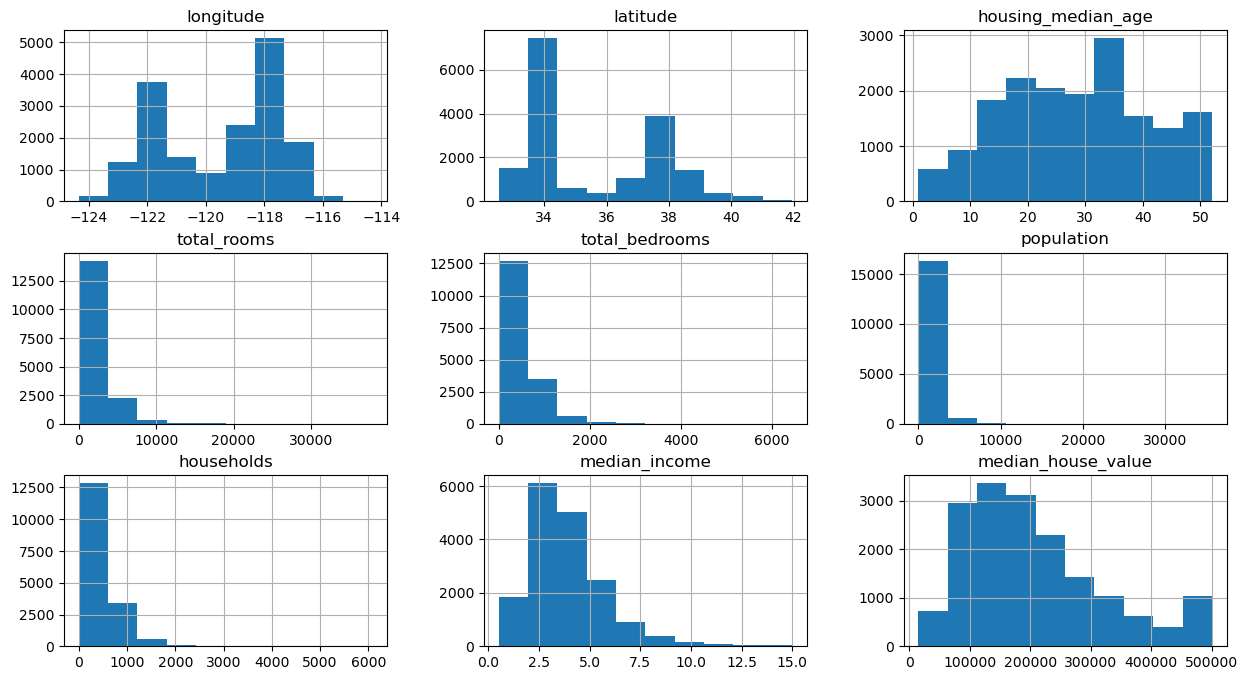

In [78]:
df.hist(figsize=(15, 8));

In [79]:
df[df['total_rooms'] > 20000].shape

(26, 9)

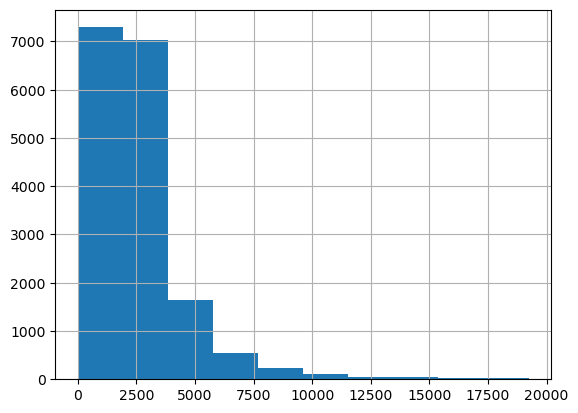

In [80]:
df = df[df['total_rooms'] < 20000]
df['total_rooms'].hist();

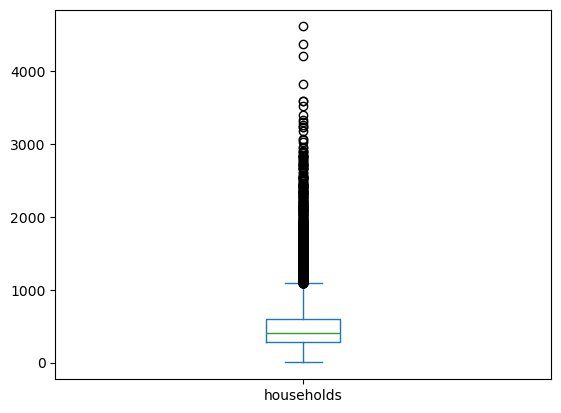

In [81]:
df['households'].plot(kind='box');

In [82]:
df[df['households'] > 1500].shape

(397, 9)

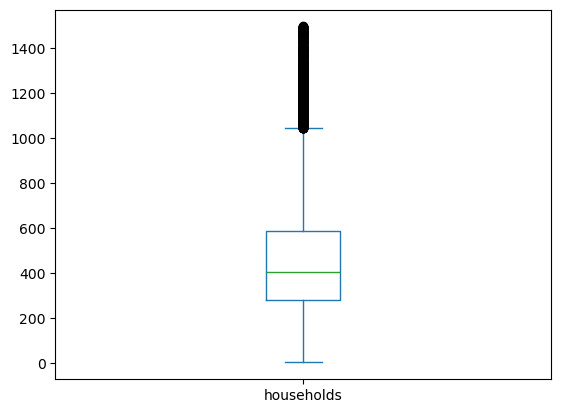

In [83]:
df = df[df['households'] < 1500]

df['households'].plot(kind='box');

#### Подсчетом

##### Межквартильный размах

In [84]:
df['total_bedrooms'].describe()

count    16576.000000
mean       494.840432
std        297.512860
min          1.000000
25%        294.000000
50%        427.000000
75%        626.000000
max       3923.000000
Name: total_bedrooms, dtype: float64

In [85]:
q1 = df['total_bedrooms'].quantile(q=0.25)
q3 = df['total_bedrooms'].quantile(q=0.75)
q1, q3

(np.float64(294.0), np.float64(626.0))

In [86]:
iqr = 1.5 * (q3 - q1)

left = q1 - iqr
right = q3 + iqr

left, right

(np.float64(-204.0), np.float64(1124.0))

In [87]:
df[~(df['total_bedrooms'].between(left, right))]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-114.31,34.19,15.0,5612.0,1283.0,1015.0,472.0,1.4936,66900.0
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
8,-114.59,33.61,34.0,4789.0,1175.0,3134.0,1056.0,2.1782,58400.0
115,-115.85,34.20,34.0,3868.0,1257.0,890.0,423.0,1.3571,41000.0
135,-116.09,34.15,13.0,9444.0,1997.0,4166.0,1482.0,2.6111,65600.0
...,...,...,...,...,...,...,...,...,...
16490,-122.63,38.26,7.0,7808.0,1390.0,3551.0,1392.0,4.6069,202300.0
16546,-122.67,38.33,4.0,8072.0,1606.0,4323.0,1475.0,3.9518,220300.0
16569,-122.69,38.36,6.0,5496.0,1374.0,2502.0,1189.0,2.4827,177500.0
16587,-122.70,38.39,16.0,4922.0,1211.0,2557.0,1088.0,2.0915,168100.0


##### Правило трех сигм

In [88]:
s = df['total_bedrooms'].std()
left = -3 * s + df['total_bedrooms'].mean()
right = 3 * s + df['total_bedrooms'].mean()

left, right

(np.float64(-397.6981466886329), np.float64(1387.3790105882467))

In [89]:
df[~(df['total_bedrooms'].between(left, right))]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
135,-116.09,34.15,13.0,9444.0,1997.0,4166.0,1482.0,2.6111,65600.0
186,-116.33,33.75,5.0,19107.0,3923.0,2880.0,1376.0,4.0360,158500.0
187,-116.33,33.72,11.0,12327.0,2000.0,2450.0,1139.0,7.4382,353100.0
191,-116.36,33.88,11.0,12557.0,3098.0,2453.0,1232.0,1.7844,78500.0
...,...,...,...,...,...,...,...,...,...
16429,-122.57,38.02,33.0,9531.0,1487.0,3798.0,1409.0,5.6512,314000.0
16467,-122.61,37.99,40.0,7737.0,1488.0,3108.0,1349.0,4.4375,289600.0
16490,-122.63,38.26,7.0,7808.0,1390.0,3551.0,1392.0,4.6069,202300.0
16546,-122.67,38.33,4.0,8072.0,1606.0,4323.0,1475.0,3.9518,220300.0


### Методы машинного обучения

#### OneClassSVM

<img src='https://www.researchgate.net/profile/Hany_Alashwal/publication/242572058/figure/fig1/AS:393295319584771@1470780319210/Classification-in-one-class-SVM.png' width=500>

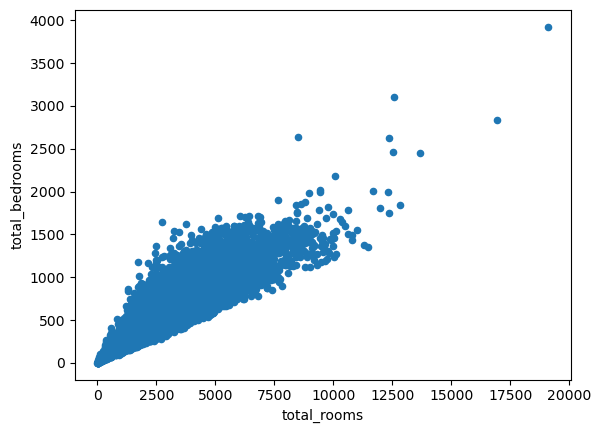

In [90]:
df.plot(kind='scatter',
        x='total_rooms',
        y='total_bedrooms');

In [91]:
from sklearn.svm import OneClassSVM

clf = OneClassSVM(nu=0.01)
clf.fit(df[['total_rooms', 'total_bedrooms']])

y_pred = clf.predict(df[['total_rooms', 'total_bedrooms']])
y_pred

array([ 1, -1,  1, ...,  1,  1,  1], shape=(16576,))

In [92]:
df[y_pred == -1]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
135,-116.09,34.15,13.0,9444.0,1997.0,4166.0,1482.0,2.6111,65600.0
186,-116.33,33.75,5.0,19107.0,3923.0,2880.0,1376.0,4.0360,158500.0
187,-116.33,33.72,11.0,12327.0,2000.0,2450.0,1139.0,7.4382,353100.0
191,-116.36,33.88,11.0,12557.0,3098.0,2453.0,1232.0,1.7844,78500.0
...,...,...,...,...,...,...,...,...,...
15846,-122.42,37.79,52.0,2737.0,1241.0,1761.0,1029.0,1.8068,225000.0
16262,-122.49,37.79,52.0,2488.0,281.0,805.0,295.0,10.7058,500001.0
16309,-122.50,37.79,52.0,8.0,1.0,13.0,1.0,15.0001,500001.0
16474,-122.62,38.40,10.0,9772.0,1308.0,3741.0,1242.0,6.5261,324700.0


C:\Users\misha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but OneClassSVM was fitted with feature names
  warnings.warn(


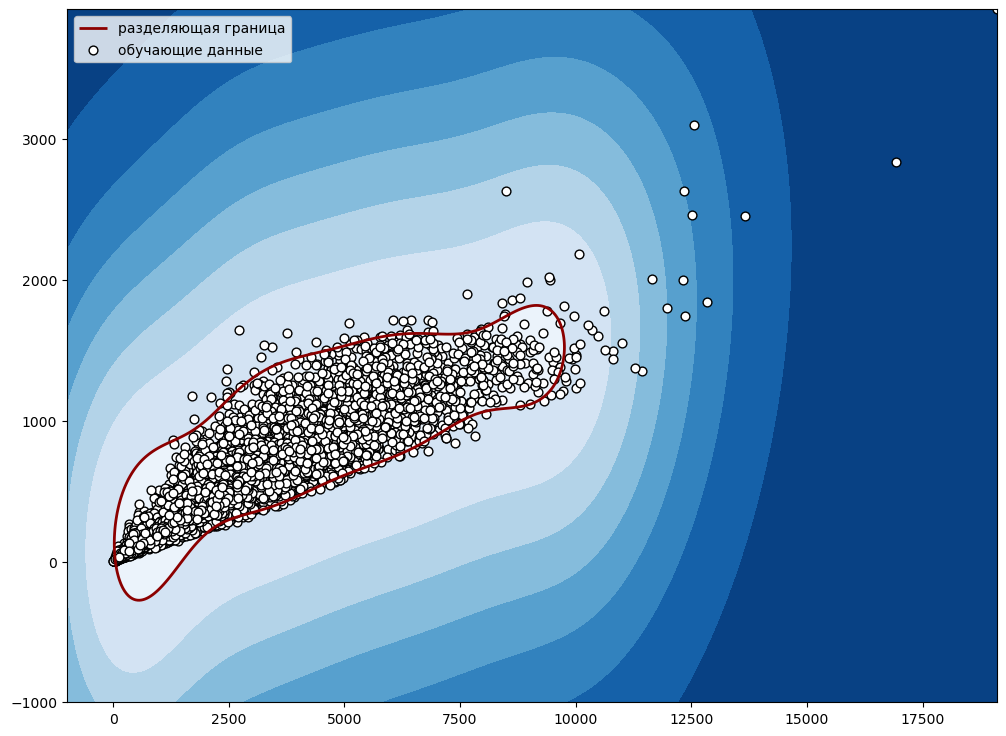

In [93]:
import matplotlib.pyplot as plt


xx, yy = np.meshgrid(np.linspace(-1000, df['total_rooms'].max(), 500),
                     np.linspace(-1000, df['total_bedrooms'].max(), 500))

Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(12,9))
a = plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='darkred')
plt.contourf(xx, yy, Z, cmap=plt.cm.Blues_r)

s = 40
b1 = plt.scatter(df['total_rooms'], df['total_bedrooms'], c='white', s=s, edgecolors='k')

# UPD 2025-07-30. Изменился атрибут на метод
# plt.legend([a.collections[0], b1],
#            ["разделяющая граница", "обучающие данные"],
#            loc="upper left");

plt.legend([a.legend_elements()[0][0], b1],
           ["разделяющая граница", "обучающие данные"],
           loc="upper left");

In [94]:
from sklearn.svm import OneClassSVM

clf = OneClassSVM(nu=0.01)
clf.fit(df)

y_pred = clf.predict(df)
df[y_pred == -1]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
17,-114.65,32.79,21.0,44.0,33.0,64.0,27.0,0.8571,25000.0
19,-114.67,33.92,17.0,97.0,24.0,29.0,15.0,1.2656,27500.0
36,-115.46,33.19,33.0,1234.0,373.0,777.0,298.0,1.0000,40000.0
46,-115.51,33.24,32.0,1995.0,523.0,1069.0,410.0,1.6552,43300.0
50,-115.52,34.22,30.0,540.0,136.0,122.0,63.0,1.3333,42500.0
...,...,...,...,...,...,...,...,...,...
16512,-122.64,37.96,29.0,377.0,58.0,151.0,67.0,9.5551,500001.0
16643,-122.74,39.71,16.0,255.0,73.0,85.0,38.0,1.6607,14999.0
16801,-123.17,40.31,36.0,98.0,28.0,18.0,8.0,0.5360,14999.0
16823,-123.22,40.16,27.0,1848.0,449.0,396.0,150.0,2.8472,41300.0


#### Isolation Forest

<img src='https://www.mdpi.com/computers/computers-11-00054/article_deploy/html/images/computers-11-00054-g003.png'>

In [95]:
from sklearn.ensemble import IsolationForest

clf = IsolationForest(random_state=1, contamination=0.01)
clf.fit(df[['total_rooms', 'total_bedrooms']])

y_pred = clf.predict(df[['total_rooms', 'total_bedrooms']])
y_pred

array([ 1, -1,  1, ...,  1,  1,  1], shape=(16576,))

In [96]:
df[y_pred == -1]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
135,-116.09,34.15,13.0,9444.0,1997.0,4166.0,1482.0,2.6111,65600.0
186,-116.33,33.75,5.0,19107.0,3923.0,2880.0,1376.0,4.0360,158500.0
187,-116.33,33.72,11.0,12327.0,2000.0,2450.0,1139.0,7.4382,353100.0
191,-116.36,33.88,11.0,12557.0,3098.0,2453.0,1232.0,1.7844,78500.0
...,...,...,...,...,...,...,...,...,...
16429,-122.57,38.02,33.0,9531.0,1487.0,3798.0,1409.0,5.6512,314000.0
16454,-122.60,38.11,23.0,8642.0,1294.0,3594.0,1253.0,5.3962,301500.0
16467,-122.61,37.99,40.0,7737.0,1488.0,3108.0,1349.0,4.4375,289600.0
16474,-122.62,38.40,10.0,9772.0,1308.0,3741.0,1242.0,6.5261,324700.0


C:\Users\misha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


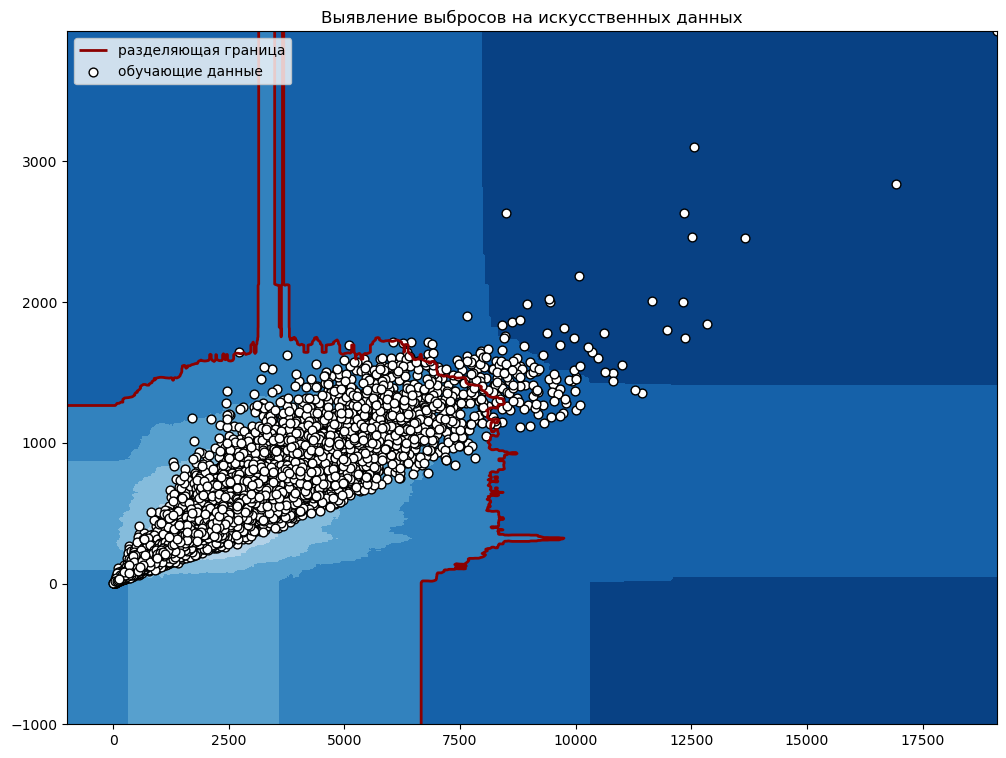

In [97]:
import matplotlib.pyplot as plt


xx, yy = np.meshgrid(np.linspace(-1000, df['total_rooms'].max(), 500),
                     np.linspace(-1000, df['total_bedrooms'].max(), 500))

Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(12,9))
plt.title("Выявление выбросов на искусственных данных")

a = plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='darkred')
plt.contourf(xx, yy, Z, cmap=plt.cm.Blues_r)

s = 40
b1 = plt.scatter(df['total_rooms'], df['total_bedrooms'], c='white', s=s, edgecolors='k')

# UPD 2025-07-30. Изменился атрибут на метод
# plt.legend([a.collections[0], b1],
#            ["разделяющая граница", "обучающие данные"],
#            loc="upper left");

plt.legend([a.legend_elements()[0][0], b1],
           ["разделяющая граница", "обучающие данные"],
           loc="upper left");

#### KNN

In [98]:
from sklearn.neighbors import LocalOutlierFactor


clf = LocalOutlierFactor(novelty=True)
clf.fit(df[['total_rooms', 'total_bedrooms']])

y_pred = clf.predict(df[['total_rooms', 'total_bedrooms']])
y_pred

C:\Users\misha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


array([ 1, -1,  1, ...,  1,  1,  1], shape=(16576,))

In [99]:
df[y_pred == -1]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
17,-114.65,32.79,21.0,44.0,33.0,64.0,27.0,0.8571,25000.0
186,-116.33,33.75,5.0,19107.0,3923.0,2880.0,1376.0,4.0360,158500.0
187,-116.33,33.72,11.0,12327.0,2000.0,2450.0,1139.0,7.4382,353100.0
191,-116.36,33.88,11.0,12557.0,3098.0,2453.0,1232.0,1.7844,78500.0
...,...,...,...,...,...,...,...,...,...
15865,-122.42,37.76,37.0,1291.0,588.0,1846.0,557.0,1.3365,225000.0
15992,-122.44,37.79,52.0,1335.0,151.0,402.0,157.0,10.8783,500001.0
16102,-122.46,37.79,52.0,899.0,96.0,304.0,110.0,14.2959,500001.0
16262,-122.49,37.79,52.0,2488.0,281.0,805.0,295.0,10.7058,500001.0


C:\Users\misha\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LocalOutlierFactor was fitted with feature names
  warnings.warn(


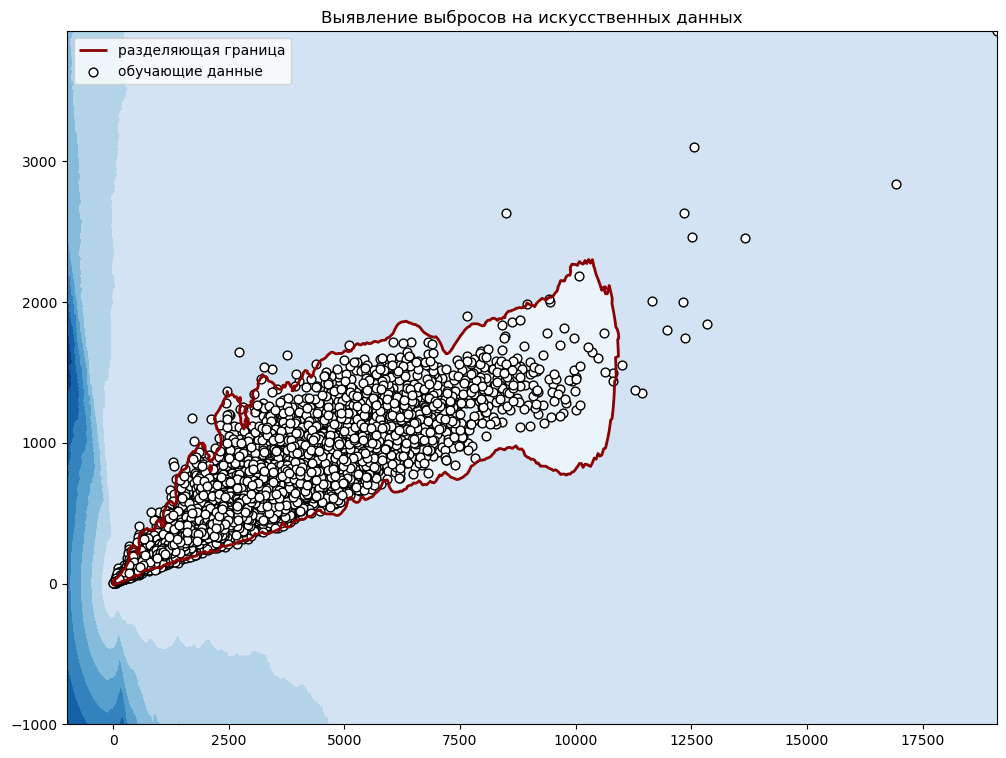

In [100]:
import matplotlib.pyplot as plt


xx, yy = np.meshgrid(np.linspace(-1000, df['total_rooms'].max(), 500),
                     np.linspace(-1000, df['total_bedrooms'].max(), 500))

Z = clf.decision_function(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)
plt.figure(figsize=(12,9))
plt.title("Выявление выбросов на искусственных данных")

a = plt.contour(xx, yy, Z, levels=[0], linewidths=2, colors='darkred')
plt.contourf(xx, yy, Z, cmap=plt.cm.Blues_r)

s = 40
b1 = plt.scatter(df['total_rooms'], df['total_bedrooms'], c='white', s=s, edgecolors='k')

# UPD 2025-07-30. Изменился атрибут на метод
# plt.legend([a.collections[0], b1],
#            ["разделяющая граница", "обучающие данные"],
#            loc="upper left");

plt.legend([a.legend_elements()[0][0], b1],
           ["разделяющая граница", "обучающие данные"],
           loc="upper left");

#### DBSCAN

<img src='https://upload.wikimedia.org/wikipedia/commons/thumb/a/af/DBSCAN-Illustration.svg/400px-DBSCAN-Illustration.svg.png'>

In [101]:
X = StandardScaler().fit_transform(df[['total_rooms', 'total_bedrooms']])

In [102]:
from sklearn.cluster import DBSCAN


db = DBSCAN(eps=0.5, min_samples=5).fit(X)
core_samples_mask = np.zeros_like(db.labels_, dtype=bool)
core_samples_mask[db.core_sample_indices_] = True
labels = db.labels_

In [103]:
labels

array([ 0, -1,  0, ...,  0,  0,  0], shape=(16576,))

In [104]:
df[labels == -1]

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
1,-114.47,34.40,19.0,7650.0,1901.0,1129.0,463.0,1.8200,80100.0
186,-116.33,33.75,5.0,19107.0,3923.0,2880.0,1376.0,4.0360,158500.0
187,-116.33,33.72,11.0,12327.0,2000.0,2450.0,1139.0,7.4382,353100.0
191,-116.36,33.88,11.0,12557.0,3098.0,2453.0,1232.0,1.7844,78500.0
199,-116.38,33.71,17.0,12509.0,2460.0,2737.0,1423.0,4.5556,258100.0
203,-116.39,33.69,10.0,11659.0,2007.0,2186.0,1083.0,6.9833,238800.0
210,-116.42,33.76,14.0,16921.0,2837.0,2524.0,1262.0,7.6281,341700.0
242,-116.51,34.45,21.0,8502.0,2634.0,2330.0,991.0,1.3811,51300.0
253,-116.53,33.85,16.0,10077.0,2186.0,3048.0,1337.0,2.9647,110900.0
389,-116.94,34.24,27.0,12342.0,2630.0,1300.0,566.0,1.9980,153500.0


In [105]:
core_samples_mask

array([ True, False,  True, ...,  True,  True,  True], shape=(16576,))

Кол-во кластеров 1
Кол-во шума 16


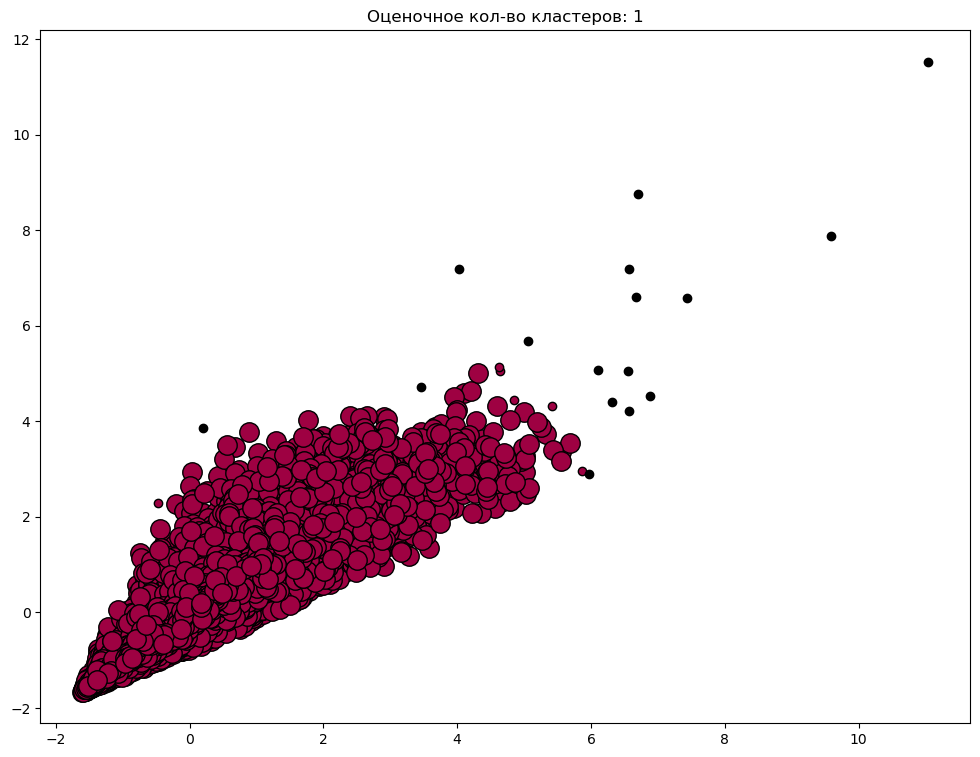

In [106]:
# Количество кластеров в метках без учета шума
n_clusters_ = len(set(labels)) - (1 if -1 in labels else 0)
n_noise_ = list(labels).count(-1)

print('Кол-во кластеров', n_clusters_)
print('Кол-во шума', n_noise_)

# Отрисовка результата
plt.figure(figsize=(12,9))
unique_labels = set(labels)
colors = [plt.cm.Spectral(each)
          for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Черный цвет используется для выявления шума
        col = [0, 0, 0, 1]

    class_member_mask = (labels == k)

    xy = X[class_member_mask & core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=14)

    xy = X[class_member_mask & ~core_samples_mask]
    plt.plot(xy[:, 0], xy[:, 1], 'o', markerfacecolor=tuple(col),
             markeredgecolor='k', markersize=6)

plt.title('Оценочное кол-во кластеров: %d' % n_clusters_)
plt.show()

# Дополнительные материалы

1. Что делать с пропусками https://youtu.be/lg3H1Kd0E4o
2. Работа с пропусками в pandas https://youtu.be/cmvLTIBI_eY
3. Работа с пропусками в sklearn https://youtu.be/o3MuMzaVglI
4. KNN https://youtu.be/m_bWhOLr_XM
5. Случайный лес https://youtu.be/rawnIo_XtYY
